Binned acquisition
==================

In this tutorial, we will demonstrate the sequencer-based acquisition binning procedure. The binning process is applied on the input path after real-time demodulation, (weighed) integration, IQ rotation and discretization. It allows storing both the integration and discretization
results on the fly without intervention of the host PC in up to 131072 bins. It also allows the averaging of those bins on the fly
(see section [Sequencer Acquisition](https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/cluster/q1_sequence_processor.html#acquisitions)).
We will then use the module sequencers to sequence waveforms on the outputs and, simultaneously, acquire the resulting waveforms on the inputs.

Setup
-----

First, we are going to import the required packages.

We will show this by using a QRM and directly connecting outputs $\text{O}^{[1-2]}$ to inputs $\text{I}^{[1-2]}$, respectively.

In [1]:
import json
import math

import matplotlib.pyplot as plt
import scipy.signal

In [2]:
from __future__ import annotations

from typing import TYPE_CHECKING, Callable

from qcodes.instrument import find_or_create_instrument

from qblox_instruments import Cluster, ClusterType

if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module

### Scan For Clusters

We scan for the available devices connected via ethernet using the Plug & Play functionality of the Qblox Instruments package (see [Plug & Play](https://qblox-qblox-instruments.readthedocs-hosted.com/en/main/api_reference/tools.html#api-pnp) for more info).

In [3]:
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.1 with name "cluster-mm" and serial number 00015_2251_003


In [4]:
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"

### Connect to Cluster

We now make a connection with the Cluster.

In [5]:
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
            8: ClusterType.CLUSTER_QRM_RF,
        }
        if cluster_ip is None
        else None
    ),
)

#### Get connected modules

In [6]:
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }

In [7]:
# QRM modules
modules = get_connected_modules(cluster, lambda mod: mod.is_qrm_type and not mod.is_rf_type)
print(modules)

{4: <Module: cluster0_module4 of Cluster: cluster0>}


In [8]:
# This uses the module of the correct type with the lowest slot index
module = list(modules.values())[0]
print(module)

<Module: cluster0_module4 of Cluster: cluster0>


### Reset the Cluster

We reset the Cluster to enter a well-defined state. Note that resetting will clear all stored parameters, so resetting between experiments is usually not desirable.

In [9]:
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


Generate waveforms and weights<a id='gen_wf'></a>
------------------------------

Next, we need to create the waveforms used by the sequence for playback on the outputs as well as weights used by the sequence for weighed
integrations. To keep it straightforward, we use the DC offset from the sequencers as our waveform and define waveform weights in the cell
below.

In [ ]:
# Waveform and weight parameters
waveform_weight_length = 600  # nanoseconds

# These will be used as weights in the "Weighed acquisition" section
waveforms_weights = {
    "gaussian": {
        "data": scipy.signal.windows.gaussian(
            waveform_weight_length, std=0.12 * waveform_weight_length
        ).tolist(),
        "index": 0,
    },
    "sine": {
        "data": [
            math.sin((2 * math.pi / waveform_weight_length) * i)
            for i in range(0, waveform_weight_length)
        ],
        "index": 1,
    },
    "block": {"data": [1.0 for _ in range(0, waveform_weight_length)], "index": 2},
}

Specify acquisitions
--------------------

We also need to specify the acquisitions so that the instrument can allocate the required memory for its acquisition list. In this case we will create 4 acquisition specifications that each create multiple bins.

In [11]:
# Acquisitions
acquisitions = {
    "non_weighed": {"num_bins": 10, "index": 0},
    "weighed": {"num_bins": 10, "index": 1},
    "large": {"num_bins": 16384, "index": 2},
    "avg": {"num_bins": 10, "index": 3},
    "single": {"num_bins": 1, "index": 4},
}

Create Q1ASM program
--------------------

Now that we have the waveform and acquisition specifications for the sequence, we need a simple Q1ASM program that sequences the waveforms and triggers the acquisitions.
In this case we will simply trigger 10 non-weighed acquisitions and store each acquisition in a separate bin.

In [12]:
# Sequence program.
seq_prog = """
      move    0,R0        #Loop iterator.
      nop

loop: acquire 0,R0,1200  #Acquire bins and store them in "non_weighed" acquisition.
      add     R0,1,R0     #Increment iterator
      nop                 #Wait a cycle for R0 to be available.
      jlt     R0,10,@loop #Run until number of iterations is done.

      stop                #Stop.
"""

Upload sequence
---------------

Now that we have the waveform, weights and acquisition specifications and Q1ASM program, we can combine them in a sequence stored in a JSON file.

In [13]:
# Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
sequence = {
    "waveforms": waveforms_weights,
    "weights": waveforms_weights,
    "acquisitions": acquisitions,
    "program": seq_prog,
}
with open("sequence.json", "w", encoding="utf-8") as file:
    json.dump(sequence, file, indent=4)
    file.close()

Let's write the JSON file to the instruments. We will use sequencer 0, which will drive outputs $\text{O}^{[1-2]}$ and acquire on inputs $\text{I}^{[1-2]}$.

In [14]:
# Upload sequence.
module.sequencer0.sequence("sequence.json")

Play sequence
-------------

The sequence has been uploaded to the instrument. Now we need to configure the sequencers. To keep it simple we will set a DC signal on the outputs of the instrument by enabling the sequencer offsets and disabling the modulation. These DC signals will then be acquired through the inputs. As such, we will also disable the demodulation on the input path. Furthermore, since we are running non-weighed integrations, we need to specify the integration length. This integration length will be used for every non-weighed integration moving forward. We will also put the integration result acquisition rotation to 0 degrees and acquisition threshold to 0.

In [15]:
# Map sequencer to specific outputs (but first disable all sequencer connections)
module.disconnect_outputs()
module.disconnect_inputs()

In [16]:
module.sequencer0.connect_sequencer("io0_1")

In [17]:
# Configure scope mode
module.scope_acq_sequencer_select(0)
module.scope_acq_trigger_mode_path0("sequencer")
module.scope_acq_trigger_mode_path1("sequencer")

# Set AWG offsets
module.sequencer0.offset_awg_path0(0.5)
module.sequencer0.offset_awg_path1(0.5)

# Configure integration
module.sequencer0.integration_length_acq(1200)
module.sequencer0.thresholded_acq_rotation(0)
module.sequencer0.thresholded_acq_threshold(0)

In [18]:
# Configure the sequencer
module.sequencer0.mod_en_awg(False)
module.sequencer0.demod_en_acq(False)

Now let's start the sequence.

In [19]:
# Arm and start sequencer.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of sequencer.
print(module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_BINNING_DONE, Warning Flags: NONE, Error Flags: NONE, Log: []


Retrieve acquisition
--------------------

Next, we will have a quick look at the input signal so that we can compare it to the integration results. Since we are integrating over a DC signal we are expecting the integration results to be roughly equal to the average DC value.

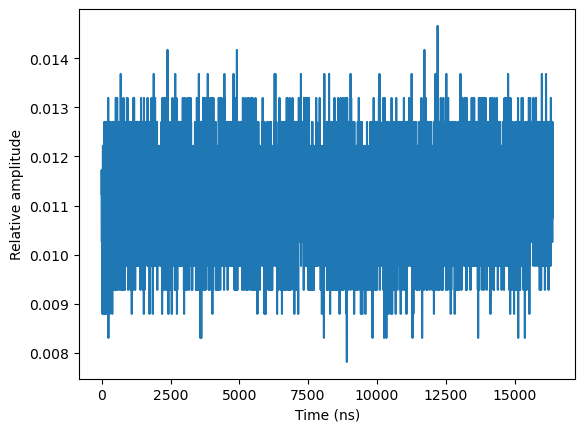

In [20]:
# Wait for the sequencer to stop with a timeout period of one minute.
module.get_acquisition_status(0)

# Move acquisition data from temporary memory to acquisition list.
module.store_scope_acquisition(0, "non_weighed")

# Get acquisition list from instrument.
non_weighed_acq = module.get_acquisitions(0)["non_weighed"]

# Plot acquired signal on both inputs.
fig, ax = plt.subplots(1, 1)
ax.plot(non_weighed_acq["acquisition"]["scope"]["path0"]["data"][0:100000])
#ax.plot(non_weighed_acq["acquisition"]["scope"]["path1"]["data"][0:10000])
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Relative amplitude")
plt.show()

To check if the integration results match what we expect, we need to divide the integration results by the integration length which was set through the
corresponding QCoDeS parameter. Note that the 'valid' key of the dictionary indicates if the bin was actually set during the sequence.

In [21]:
int_len = module.sequencer0.integration_length_acq()
bins = non_weighed_acq["acquisition"]["bins"]
print(len(non_weighed_acq["acquisition"]["scope"]["path0"]["data"]))
print(bins)
bins["integration"]["path0"] = [(val / int_len) for val in bins["integration"]["path0"]]
bins["integration"]["path1"] = [(val / int_len) for val in bins["integration"]["path1"]]
bins

16384
{'integration': {'path0': [13.257938446507083, 13.225207620908646, 13.29457743038593, 13.45627747923791, 13.322423058133854, 13.400586223742062, 13.344406448461163, 13.450415241817293, 13.322911577918905, 13.344406448461163], 'path1': [1.8832437713727406, 1.8886174890083047, 1.8876404494382022, 1.9345383488031265, 1.9745969711773326, 1.9379579872984856, 2.1118710307767463, 1.9926722032242306, 1.850512945774304, 1.8104543234000976]}, 'threshold': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 'avg_cnt': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


{'integration': {'path0': [0.011048282038755903,
   0.011021006350757206,
   0.011078814525321608,
   0.011213564566031592,
   0.011102019215111544,
   0.011167155186451718,
   0.011120338707050969,
   0.011208679368181077,
   0.01110242631493242,
   0.011120338707050969],
  'path1': [0.0015693698094772837,
   0.0015738479075069207,
   0.0015730337078651685,
   0.001612115290669272,
   0.0016454974759811105,
   0.0016149649894154046,
   0.0017598925256472886,
   0.0016605601693535255,
   0.0015420941214785867,
   0.0015087119361667479]},
 'threshold': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'avg_cnt': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [157]:
print(sum(non_weighed_acq["acquisition"]["scope"]["path0"]["data"][0:16000])/16000)

0.010843734733756135


In [155]:
print(int_len)

16000


In [22]:
non_weighed_acq

{'index': 0,
 'acquisition': {'scope': {'path0': {'data': [0.011235955056179775,
     0.01074743527112848,
     0.01172447484123107,
     0.01172447484123107,
     0.010258915486077186,
     0.01074743527112848,
     0.010258915486077186,
     0.01074743527112848,
     0.01074743527112848,
     0.01172447484123107,
     0.01074743527112848,
     0.011235955056179775,
     0.01074743527112848,
     0.01074743527112848,
     0.011235955056179775,
     0.01172447484123107,
     0.01074743527112848,
     0.010258915486077186,
     0.011235955056179775,
     0.01074743527112848,
     0.010258915486077186,
     0.01074743527112848,
     0.009770395701025891,
     0.011235955056179775,
     0.011235955056179775,
     0.01074743527112848,
     0.01074743527112848,
     0.011235955056179775,
     0.008793356130923302,
     0.011235955056179775,
     0.01074743527112848,
     0.009770395701025891,
     0.01074743527112848,
     0.01074743527112848,
     0.009770395701025891,
     0.0102589154860

Weighed acquisition
-------------------

In the following, we look into weighed integrations. This refers to integration with a weighting given by a particular weight that we specified earlier. This is equivalent to multiplying the acquired trace with a function (which specifies the weighting) and integrating the result.

To do this, we will need to modify the sequence program slightly and reupload it. We will be using a gaussian weight to integrate over input path 0 and a sine weight to integrate over input path 1. The integration length of a weighed integration is determined by the weight length.

In [124]:
# Sequence program.
seq_prog = """
      move            0,R0            #Loop iterator.
      move            0,R1            #Weight for path 0.
      move            1,R2            #Weight for path 1.
      nop

loop: acquire_weighed 1,R0,R1,R2,1200 #Acquire bins and store them in "weighed" acquisition.
      add             R0,1,R0         #Increment iterator
      nop                             #Wait a cycle for R0 to be available.
      jlt             R0,10,@loop     #Run until number of iterations is done.

      stop                            #Stop.
"""

In [125]:
# Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
sequence = {
    "waveforms": waveforms_weights,
    "weights": waveforms_weights,
    "acquisitions": acquisitions,
    "program": seq_prog,
}
with open("sequence.json", "w", encoding="utf-8") as file:
    json.dump(sequence, file, indent=4)
    file.close()

In [126]:
# Upload sequence.
module.sequencer0.sequence("sequence.json")

Let's start the sequence and retrieve the results.

In [127]:
# Arm and start sequencer.
module.arm_sequencer(0)  # Arm sequencer 0
module.start_sequencer()  # Start all armed sequencers

# Print status of sequencer.
print(module.get_sequencer_status(0))

Status: OKAY, State: STOPPED, Info Flags: ACQ_SCOPE_DONE_PATH_0, ACQ_SCOPE_DONE_PATH_1, ACQ_BINNING_DONE, Warning Flags: NONE, Error Flags: NONE, Log: []


In [128]:
# Wait for the sequencer to stop with a timeout period of one minute.
module.get_acquisition_status(0)

# Get acquisition list from instrument.
weighed_acq = module.get_acquisitions(0)["weighed"]

To check if the integration results match what we expect we need to divide the integration results by the integration length again. In this case the integration
length is determined by the length of the weights.

In [129]:
int_len = waveform_weight_length
bins = weighed_acq["acquisition"]["bins"]
bins["integration"]["path0"] = [(val / int_len) for val in bins["integration"]["path0"]]
bins["integration"]["path1"] = [(val / int_len) for val in bins["integration"]["path1"]]
bins

{'integration': {'path0': [0.003246805032079943,
   0.003265957616911233,
   0.0033172669111890757,
   0.003233360595298866,
   0.0033009168914167925,
   0.0032524976677774306,
   0.0032456495606782384,
   0.003238449044745342,
   0.0032207049019909667,
   0.0032035367050505916],
  'path1': [-1.1340723099969477e-05,
   4.7146812963267464e-05,
   -6.143607633891292e-05,
   -4.000198239912774e-06,
   -3.6714954631936815e-05,
   -7.95704144272199e-05,
   -3.763416096905906e-05,
   -5.382865946145725e-05,
   -0.00011468759672846868,
   -4.758473861327681e-05]},
 'threshold': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'avg_cnt': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Large number of bins
--------------------
The QRM supports up to 131072 bins. To show that, we need to change the program slightly. We will use the non-weighed acquisition program,
however, we will now loop over the maximum number of acquisitions while storing each result in a separate bin.

In [34]:
# Sequence program.
seq_prog = """
      move    0,R0            #Loop iterator.
      nop

loop: acquire 2,R0,1200     #Acquire bins and store them in "large" acquisition.
      add     R0,1,R0         #Increment iterator
      nop                     #Wait a cycle for R0 to be available.
      jlt     R0,16384,@loop #Run until number of iterations is done.

      stop                    #Stop.
"""

In [35]:
# Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
sequence = {
    "waveforms": waveforms_weights,
    "weights": waveforms_weights,
    "acquisitions": acquisitions,
    "program": seq_prog,
}
with open("sequence.json", "w", encoding="utf-8") as file:
    json.dump(sequence, file, indent=4)
    file.close()

In [36]:
# Upload sequence.
module.sequencer0.sequence("sequence.json")

Let's start the sequence and retrieve the results.

In [37]:
# Arm and start sequencer.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of sequencer.
print(module.get_sequencer_status(0))

Status: OKAY, State: RUNNING, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


In [38]:
# Wait for the sequencer to stop with a timeout period of one minute.
module.get_acquisition_status(0, timeout=1)

# Get acquisition list from instrument.
large_acq = module.get_acquisitions(0)["large"]

Since the number of bins is now too large to simply print, we will check the number of bins and we will check the bins for NaN values which indicate that a bin is not written.

In [39]:
int_len = module.sequencer0.integration_length_acq()
bins = large_acq["acquisition"]["bins"]
bins["integration"]["path0"] = [(val / int_len) for val in bins["integration"]["path0"]]
bins["integration"]["path1"] = [(val / int_len) for val in bins["integration"]["path1"]]

print("Number of bins: {}".format(len(bins["avg_cnt"])))
for it, val in enumerate(bins["integration"]["path0"]):
    if math.isnan(val):
        raise Exception(f"NaN found at index {it}.")
for it, val in enumerate(bins["integration"]["path1"]):
    if math.isnan(val):
        raise Exception(f"NaN found at index {it}.")
print("All values are valid.")

Number of bins: 16384
All values are valid.


In [40]:
print(int_len)

1200


We will also plot the integration results in every bin to visualize the contents.

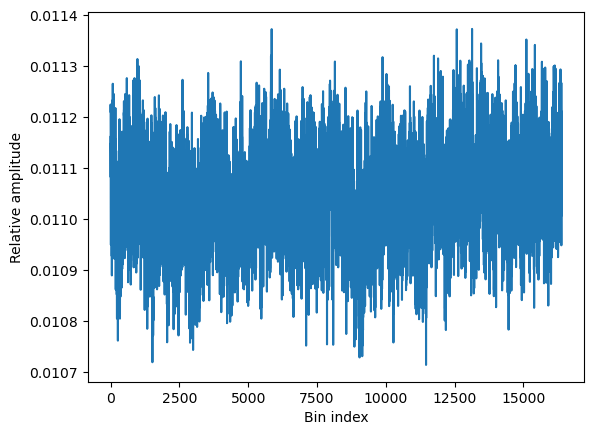

In [43]:
# Plot bins
fig, ax = plt.subplots(1, 1)
ax.plot(bins["integration"]["path0"][0:16384])
#ax.plot(bins["integration"]["path1"])
ax.set_xlabel("Bin index")
ax.set_ylabel("Relative amplitude")
plt.show()

Averaging
--------------------

As you may have noticed, the acquisition results also contain an average counter. This average counter reflects the number of times a bin has been averaged during the sequence.
Each time the sequencer writes to the same bin the results are automatically accumulated and the average counter is increased. Upon retrieval of the acquisition results, each
result is divided by the average counter and therefore automatically averaged. To show this we will change the sequence one last time. This time we will average 10 bins a 1000
times each.

In [270]:
# Sequence program.
seq_prog = """
      move    0,R1         #Average iterator.

avg:  move    0,R0         #Bin iterator.
      nop

loop: acquire 3,R0,1200    #Acquire bins and store them in "avg" acquisition.
      add     R0,1,R0      #Increment bin iterator
      nop                  #Wait a cycle for R0 to be available.
      jlt     R0,10,@loop  #Run until number of avg iterations is done.
      add     R1,1,R1      #Increment avg iterator
      nop                  #Wait a cycle for R1 to be available.
      jlt     R1,1000,@avg #Run until number of average iterations is done.

      stop                 #Stop.
"""

In [271]:
# Add sequence program, waveforms, weights and acquisitions to single dictionary and write to JSON file.
sequence = {
    "waveforms": waveforms_weights,
    "weights": waveforms_weights,
    "acquisitions": acquisitions,
    "program": seq_prog,
}
with open("sequence.json", "w", encoding="utf-8") as file:
    json.dump(sequence, file, indent=4)
    file.close()

In [272]:
# Upload sequence.
module.sequencer0.sequence("sequence.json")

Let's start the sequence and retrieve the results.

In [273]:
# Arm and start sequencer.
module.arm_sequencer(0)
module.start_sequencer()

# Print status of sequencer.
print(module.get_sequencer_status(0))

Status: OKAY, State: RUNNING, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


Note that the average count of each bin is now set to a 1000.

In [274]:
# Wait for the sequencer to stop with a timeout period of one minute.
module.get_acquisition_status(0)

# Get acquisition list from instrument.
avg_acq = module.get_acquisitions(0)["avg"]

In [275]:
int_len = module.sequencer0.integration_length_acq()
bins = avg_acq["acquisition"]["bins"]
bins["integration"]["path0"] = [(val / int_len) for val in bins["integration"]["path0"]]
bins["integration"]["path1"] = [(val / int_len) for val in bins["integration"]["path1"]]
bins

{'integration': {'path0': [0.010790816235140856,
   0.010789574173587365,
   0.010790651766813222,
   0.010790206399609184,
   0.01079322463768116,
   0.010792106334473214,
   0.010792374613255171,
   0.010791952857840742,
   0.010790987217065624,
   0.010794894968246213],
  'path1': [0.2693383679368181,
   0.26933483756717147,
   0.2693365494219182,
   0.26933713686695976,
   0.2693334892525648,
   0.2693323220973783,
   0.269339640937958,
   0.2693371869402377,
   0.269335952206481,
   0.2693379115779189]},
 'threshold': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'avg_cnt': [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]}

Stop
----

Finally, let's stop the sequencers if they haven't already and close the instrument connection. One can also display a detailed snapshot containing the instrument parameters before
closing the connection by uncommenting the corresponding lines.

In [25]:
# Stop both sequencers.
module.stop_sequencer()

# Print status of both sequencers (should now say it is stopped).
print(module.get_sequencer_status(0))
print(module.get_sequencer_status(1))
print()

# Print an overview of the instrument parameters.
print("Snapshot:")
module.print_readable_snapshot(update=True)

# Reset the cluster
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []

Snapshot:
cluster0_module4:
	parameter                    value
--------------------------------------------------------------------------------
in0_gain                      :	-6 (dB)
in0_offset                    :	0 (V)
in1_gain                      :	-6 (dB)
in1_offset                    :	0 (V)
marker0_exp0_config           :	bypassed 
marker0_exp1_config           :	bypassed 
marker0_exp2_config           :	bypassed 
marker0_exp3_config           :	bypassed 
marker0_fir_config            :	bypassed 
marker0_inv_en                :	False 
marker1_exp0_config           :	bypassed 
marker1_exp1_config           :	bypassed 
marker1_exp2_config           :	bypassed 
marker1_exp3_config           :	bypassed 
marker1_fir_config            :	bypassed 
marker1_inv_en                :	F

In [26]:
cluster.reset()